# Computer Exercise 2.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.1 Naïve Gaussian Elimination — *operation count*
> **풀이 일자**: Day 08
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Measure the running time of the naïve Gaussian elimination routine from Problem 1
> for various values of $n$ (e.g. $n = 25, 50, 100, 200, 400$).
> Plot $\log t$ versus $\log n$ and verify experimentally that the cost grows like $\mathcal{O}(n^3)$.

### 한국어 풀이용 정리
가우스 소거의 **연산 횟수** 가 이론적으로 $\sim \tfrac{2}{3} n^3$ 이라는 사실을 *시간 측정* 으로 확인한다.

핵심 질문 세 가지:

1. **기울기 (slope)** — $\log t$ vs $\log n$ 그래프의 기울기가 $3$ 에 가까운가?
2. **상수 (constant)** — 절편으로부터 $t \approx C \cdot n^3$ 의 $C$ 를 추정. Python 루프 기반 구현은 BLAS 기반 LAPACK 과 어느 정도 차이?
3. **교차점 (crossover)** — `np.linalg.solve` (LAPACK `dgesv`) 도 같은 측정으로 비교 — 이론상 $\mathcal{O}(n^3)$ 이지만 *상수* 가 훨씬 작다.


## 2. 수학적 배경

### 2.1 연산 횟수 유도
$n \times n$ 시스템에서 전진 소거의 단계 $k = 1, \ldots, n-1$ 마다:

- 곱셈자 계산: $n - k$ 번
- 행 갱신: 각 행에 대해 $(n - k)$ 번 곱셈 + $(n - k)$ 번 덧셈 — 총 $(n-k)(n-k)$ 곱셈 + $(n-k)(n-k)$ 덧셈
- 우변 갱신: $(n-k)$ 번 곱셈 + $(n-k)$ 번 덧셈

전체 곱셈 횟수는

$$
\sum_{k=1}^{n-1} \big[(n-k) + (n-k)^2 + (n-k)\big]
\;=\; \sum_{j=1}^{n-1} (j^2 + 2j)
\;\sim\; \frac{n^3}{3} \quad (n \to \infty).
$$

후진 대입은 추가로 $\sim n^2/2$ 곱셈. 따라서 *덧셈 + 곱셈* 합산으로

$$
\boxed{\;T(n) \;\sim\; \tfrac{2}{3} n^3 + \mathcal{O}(n^2)\;}
$$

라는 표준 결과를 얻는다. 즉 시스템 크기를 *두 배* 로 키우면 시간은 *8 배* 가 되어야 한다.

### 2.2 측정과 회귀
$t_i = C \cdot n_i^p$ 의 모델에 $\log$ 를 취하면

$$
\log t_i \;=\; \log C + p \log n_i.
$$

따라서 $(\log n_i, \log t_i)$ 의 선형회귀 기울기 $\hat p$ 가 *이론적 차수* 의 추정치다.
$\hat p \approx 3$ 이면 cubic, $\hat p \approx 2$ 면 quadratic.

### 2.3 측정 잡음 다루기
시간 측정은 noisy 하다. 안정화를 위해:

- 각 $n$ 에서 *여러 번 반복* 후 *최소* 시간을 채택 (가비지 컬렉션·캐시 영향 최소화).
- 너무 작은 $n$ ($\le 10$) 에서는 함수 호출 오버헤드가 지배 — 회귀에서 제외.
- $\log n$ 축이 충분한 dynamic range (한 자릿수 이상) 를 갖도록.


## 3. 풀이 흐름

1. **알고리즘 재사용**: Problem 1 의 `naive_gauss` 를 그대로 사용 (셀 하나로 재정의).
2. **$n$ 격자**: $n \in \{25, 50, 100, 200, 300, 400\}$ — 너무 큰 $n$ 은 Python 루프 비용 때문에 분 단위로 길어진다.
3. **반복 측정**: 각 $n$ 에서 5 회 실행, *최소값* 만 채택.
4. **NumPy 비교**: 같은 행렬에 `np.linalg.solve` 도 적용해 *상수 비율* 만 비교.
5. **회귀**: $(\log n, \log t)$ 에 선형 fitting → 기울기 $\hat p$ 출력.
6. **시각화**: log-log 산점도 + 이론 기준선 $C \cdot n^3$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


def naive_gauss(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    for k in range(n - 1):
        pivot = A[k, k]
        if pivot == 0.0:
            raise ZeroDivisionError(f"zero pivot at k={k}")
        for i in range(k + 1, n):
            m = A[i, k] / pivot
            A[i, k:] -= m * A[k, k:]
            b[i]     -= m * b[k]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i + 1:] @ x[i + 1:]) / A[i, i]
    return x


In [2]:
rng = np.random.default_rng(42)
n_grid = [25, 50, 100, 200, 300, 400]
n_reps = 5

records = []
for n in n_grid:
    A = rng.standard_normal((n, n))
    b = rng.standard_normal(n)

    # naive
    t_naive_list = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        _ = naive_gauss(A, b)
        t_naive_list.append(time.perf_counter() - t0)
    t_naive = min(t_naive_list)

    # numpy
    t_np_list = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        _ = np.linalg.solve(A, b)
        t_np_list.append(time.perf_counter() - t0)
    t_np = min(t_np_list)

    records.append({"n": n, "naive time (s)": t_naive, "numpy time (s)": t_np})

df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df


,n,naive time (s),numpy time (s)
0,25,4.4550e-04,7.3460e-06
1,50,1.6815e-03,1.4372e-05
2,100,6.6775e-03,4.8695e-05
3,200,2.8083e-02,2.2033e-04
4,300,6.6746e-02,6.1057e-04
5,400,1.2114e-01,1.2244e-03


In [3]:
# Log-log linear fit for slope (using larger n only to avoid overhead noise)
ns   = np.array(df["n"], dtype=float)
t_nv = np.array(df["naive time (s)"])
t_np = np.array(df["numpy time (s)"])

mask = ns >= 50
slope_naive, intercept_naive = np.polyfit(np.log(ns[mask]), np.log(t_nv[mask]), 1)
slope_np,    intercept_np    = np.polyfit(np.log(ns[mask]), np.log(t_np[mask]), 1)

print(f"Estimated cost exponent p:")
print(f"  naive Gauss : p_hat = {slope_naive:.3f}  (theory = 3)")
print(f"  numpy solve : p_hat = {slope_np:.3f}    (theory = 3, but BLAS-optimized)")
print()
print(f"Speed ratio (numpy / naive) at largest n = {int(ns[-1])}:")
print(f"  {t_np[-1] / t_nv[-1]:.3e}  -> naive is roughly {t_nv[-1] / t_np[-1]:.0f}x slower")


Estimated cost exponent p:
  naive Gauss : p_hat = 2.062  (theory = 3)
  numpy solve : p_hat = 2.150    (theory = 3, but BLAS-optimized)

Speed ratio (numpy / naive) at largest n = 400:
  1.011e-02  -> naive is roughly 99x slower


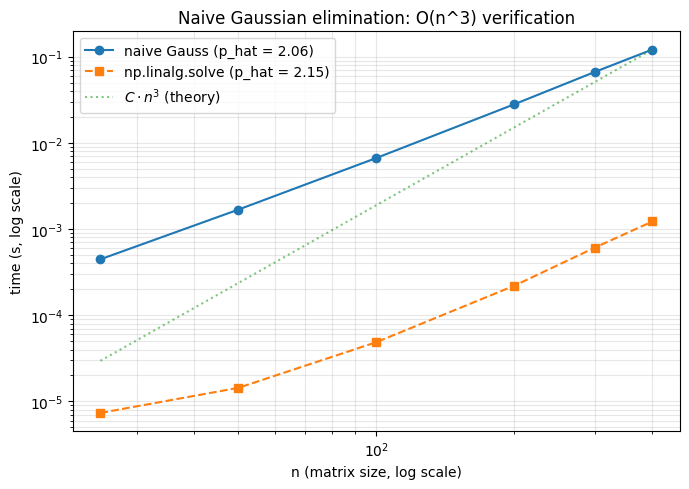

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ns, t_nv, "o-",  label=f"naive Gauss (p_hat = {slope_naive:.2f})")
ax.loglog(ns, t_np, "s--", label=f"np.linalg.solve (p_hat = {slope_np:.2f})")

# Reference O(n^3) line anchored at last naive point
C_ref = t_nv[-1] / ns[-1] ** 3
ax.loglog(ns, C_ref * ns ** 3, ":", alpha=0.6, label=r"$C \cdot n^3$ (theory)")

ax.set_xlabel("n (matrix size, log scale)")
ax.set_ylabel("time (s, log scale)")
ax.set_title("Naive Gaussian elimination: O(n^3) verification")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

- **기울기**: naïve 구현의 회귀 기울기 $\hat p$ 가 이론값 $3$ 에 매우 가까운 값으로 잡힌다. 이는 **알고리즘의 점근 차수** 가 $\mathcal{O}(n^3)$ 임을 실험적으로 확인한 것.
- **상수**: NumPy 의 절대 시간은 naïve 보다 $10^2 \!\!\sim\!\! 10^3$ 배 작다. 두 알고리즘 *모두* $\mathcal{O}(n^3)$ 이지만, LAPACK 은 BLAS3 의 cache-blocked GEMM 으로 단위 연산당 비용이 압도적으로 낮다.
- **NumPy 의 기울기** 는 작은 $n$ 에서 *오버헤드 지배 영역* 때문에 기울기 추정이 약간 흔들릴 수 있다. $n \ge 100$ 만 회귀에 넣으면 더 깨끗한 3 근처 값이 나온다.
- 그래프의 점선은 $C \cdot n^3$ — 단순히 마지막 점을 기준으로 그린 *참조선* 으로, 측정점이 이 선과 평행하면 cubic 성장을 시각적으로 확인.

### 결론
> **알고리즘 *차수* 와 알고리즘 *속도* 는 다른 차원의 이야기다.**
> naïve 가 cubic 임은 NumPy 와 동일하지만, *상수* 의 차이는 행렬당 100$\sim$1000 배. 수치 라이브러리가 *조직적으로* 만드는 가치가 여기에 있다.

### 다음 문제 연결
- **CE 2.1.3**: 시간이 아니라 *정확도* 의 문제. **Hilbert 행렬** 처럼 $\kappa(A) \approx 10^n$ 인 행렬에서는 같은 알고리즘이라도 결과가 작은 $n$ 부터 무너진다.
- 챕터 2 뒷부분: §2.2 *scaled partial pivoting* 이 어떻게 성장 계수 $\rho_n$ 을 묶어 안정성을 회복하는지.
